Anomaly Detection using KNN

Create a dummy dataset with anomalies

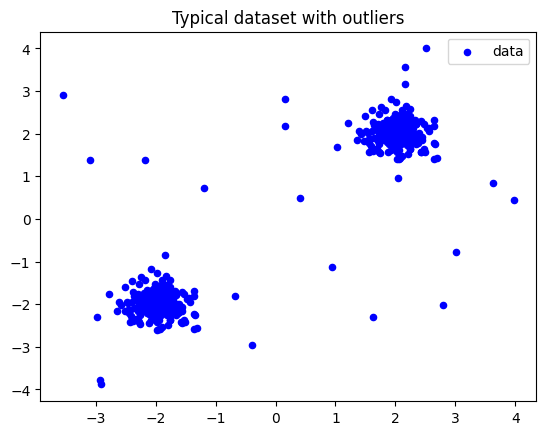

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x_inliers = 0.3 * np.random.randn(200, 2)
x_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[x_inliers + 2, x_inliers - 2, x_outliers]

plt.scatter(X[:,0], X[:,1], c='blue', s=20, label='data')
plt.title("Typical dataset with outliers")
plt.legend()
plt.show()

In [2]:
X

array([[ 2.14901425,  1.95852071],
       [ 2.19430656,  2.45690896],
       [ 1.92975399,  1.92975891],
       [ 2.47376384,  2.23023042],
       [ 1.85915768,  2.16276801],
       [ 1.86097469,  1.86028107],
       [ 2.07258868,  1.42601593],
       [ 1.48252465,  1.83131374],
       [ 1.69615066,  2.0942742 ],
       [ 1.72759278,  1.57630889],
       [ 2.43969463,  1.93226711],
       [ 2.02025846,  1.57257554],
       [ 1.83668518,  2.03327678],
       [ 1.65470193,  2.11270941],
       [ 1.81980839,  1.91249188],
       [ 1.81948802,  2.55568346],
       [ 1.99595083,  1.68268672],
       [ 2.24676347,  1.63374691],
       [ 2.06265908,  1.41209896],
       [ 1.60154419,  2.05905837],
       [ 2.22153997,  2.05141048],
       [ 1.96530552,  1.90966889],
       [ 1.5564434 ,  1.78404674],
       [ 1.86180837,  2.31713667],
       [ 2.10308549,  1.47108795],
       [ 2.09722519,  1.88447532],
       [ 1.7969234 ,  2.18350289],
       [ 2.30929986,  2.27938404],
       [ 1.74823474,

Standardization

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

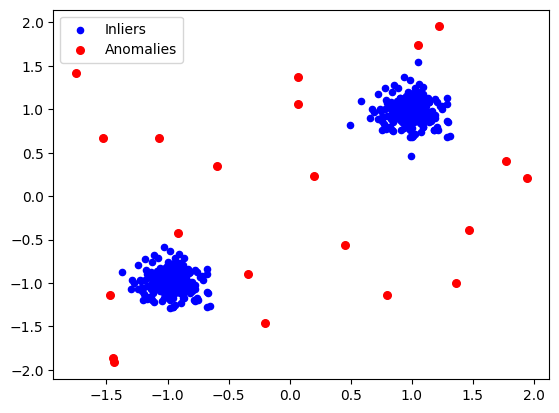

In [8]:
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
knn_scores = distances[:, -1] # distance to the 5th nearest neighbor

threshold = np.percentile(knn_scores, 95)
anomalies = X_scaled[knn_scores > threshold]

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color = 'blue', s=20, label='Inliers')
plt.scatter(anomalies[:,0], anomalies[:, 1], color='red', s=30, label='Anomalies')
plt.legend()
plt.show()

Anomaly Detection using SVM

In [14]:
from sklearn.svm import OneClassSVM

oc_svm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
oc_svm.fit(X_scaled)

labels = oc_svm.predict(X_scaled)
print(labels)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1

In [15]:
X

array([[ 2.14901425,  1.95852071],
       [ 2.19430656,  2.45690896],
       [ 1.92975399,  1.92975891],
       [ 2.47376384,  2.23023042],
       [ 1.85915768,  2.16276801],
       [ 1.86097469,  1.86028107],
       [ 2.07258868,  1.42601593],
       [ 1.48252465,  1.83131374],
       [ 1.69615066,  2.0942742 ],
       [ 1.72759278,  1.57630889],
       [ 2.43969463,  1.93226711],
       [ 2.02025846,  1.57257554],
       [ 1.83668518,  2.03327678],
       [ 1.65470193,  2.11270941],
       [ 1.81980839,  1.91249188],
       [ 1.81948802,  2.55568346],
       [ 1.99595083,  1.68268672],
       [ 2.24676347,  1.63374691],
       [ 2.06265908,  1.41209896],
       [ 1.60154419,  2.05905837],
       [ 2.22153997,  2.05141048],
       [ 1.96530552,  1.90966889],
       [ 1.5564434 ,  1.78404674],
       [ 1.86180837,  2.31713667],
       [ 2.10308549,  1.47108795],
       [ 2.09722519,  1.88447532],
       [ 1.7969234 ,  2.18350289],
       [ 2.30929986,  2.27938404],
       [ 1.74823474,

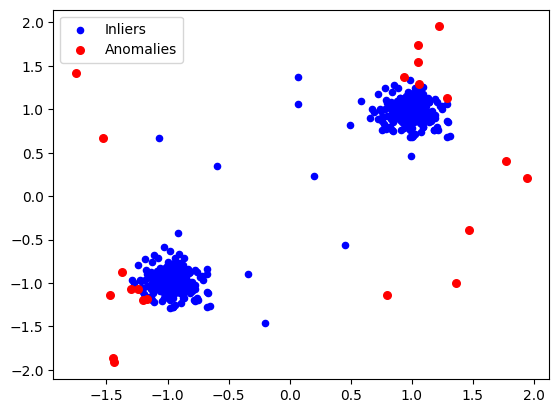

In [16]:
inliers = X_scaled[labels == 1]
anomalies = X_scaled[labels == -1]

plt.scatter(inliers[:, 0], inliers[:, 1], color = 'blue', s=20, label='Inliers')
plt.scatter(anomalies[:,0], anomalies[:, 1], color='red', s=30, label='Anomalies')
plt.legend()
plt.show()

Anomaly Detection using DBSCAN

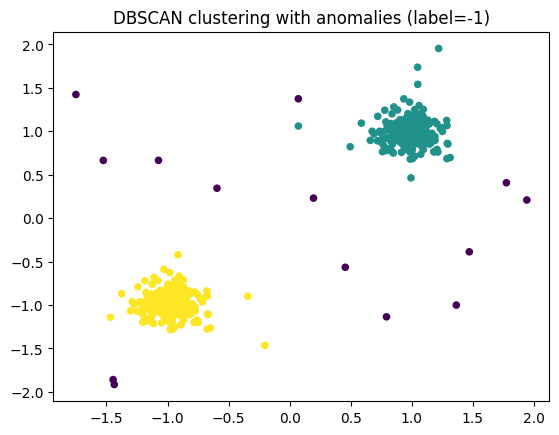

Number of anomalies: 14


In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=20)
plt.title('DBSCAN clustering with anomalies (label=-1)')
plt.show()


anomalies = X_scaled[labels == -1]
print("Number of anomalies:", len(anomalies))

Time Series Analysis

In [19]:
import pandas as pd
import numpy as np

data = pd.read_csv('/content/time_series_data.csv')
data.head()

,date,value
0,2023-01-01,55.092133
1,2023-01-02,58.164110
2,2023-01-03,64.683374
3,2023-01-04,65.164925
4,2023-01-05,69.098824


In [20]:
data.shape

(365, 2)

In [21]:
data.tail()

,date,value
360,2023-12-27,152.444790
361,2023-12-28,150.075616
362,2023-12-29,154.776850
363,2023-12-30,158.202911
364,2023-12-31,158.926059


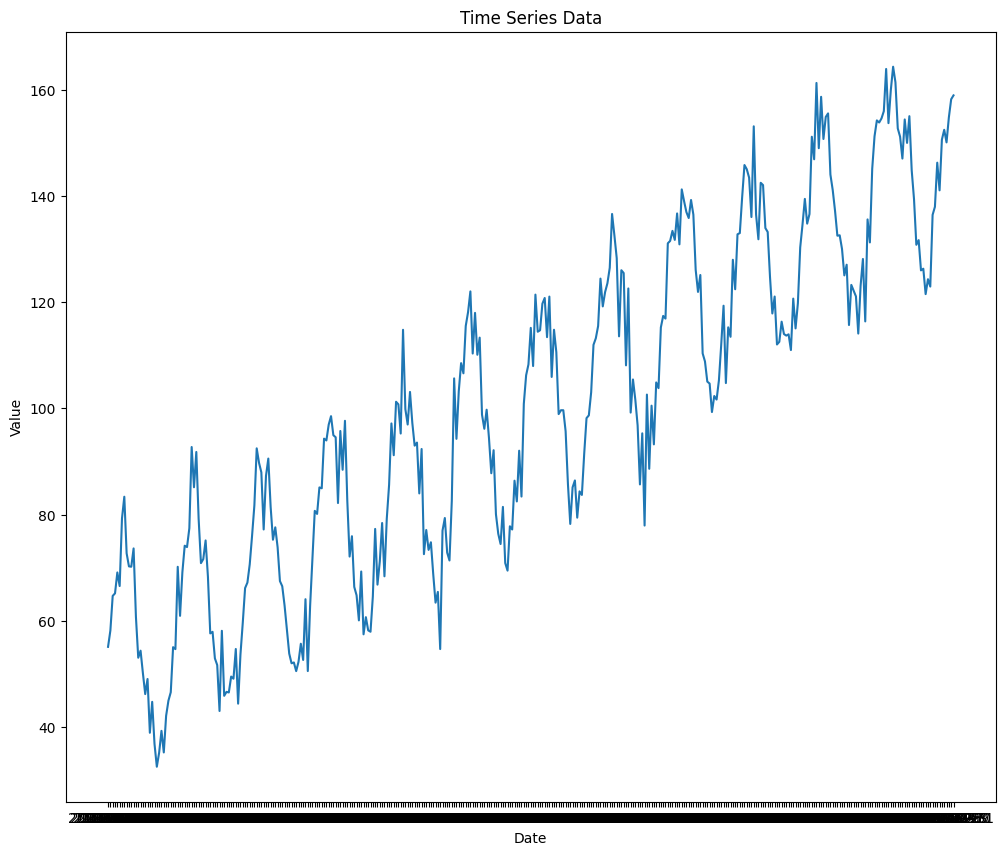

In [25]:
plt.figure(figsize=(12, 10))
plt.plot(data['date'], data['value'])
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

ARIMA Model

In [26]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(data['value'], order =(1, 1, 1))
result_arima = model_arima.fit()
result_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  value   No. Observations:                  365
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1242.311
Date:                Sat, 20 Jun 2026   AIC                           2490.622
Time:                        13:16:39   BIC                           2502.314
Sample:                             0   HQIC                          2495.269
                                - 365                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5666      0.121     -4.680      0.000      -0.804      -0.329
ma.L1          0.2545      0.144      1.763      0.078      -0.028       0.538
sigma2        53.9254      4.140     13.026      0.000      45.812      62.039
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 0.73
Prob(Q):                              0.81   Prob(JB):                         0.69
Heteroskedasticity (H):               0.90   Skew:                             0.08
Prob(H) (two-sided):                  0.57   Kurtosis:                         2.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [27]:
forecast_arima = result_arima.forecast(steps=30)
forecast_arima

,predicted_mean
365,158.866682
366,158.900322
367,158.881263
368,158.892061
369,158.885944
370,158.889410
371,158.887446
372,158.888559
373,158.887928
374,158.888285


SARIMA

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(data['value'], order =(1, 1, 1), seasonal_order=(1, 1, 1, 30))
result_sarima = model_sarima.fit()
result_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 30)   Log Likelihood               -1054.372
Date:                            Sat, 20 Jun 2026   AIC                           2118.743
Time:                                    13:21:54   BIC                           2137.799
Sample:                                         0   HQIC                          2126.341
                                            - 365                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0270      0.053     -0.508      0.611      -0.131       0.077
ma.L1         -0.9765      0.019    -51.093      0.000      -1.014      -0.939
ar.S.L30      -0.0151      0.072     -0.210      0.833      -0.156       0.125
ma.S.L30      -0.8889      0.112     -7.941      0.000      -1.108      -0.670
sigma2        27.8200      2.802      9.930      0.000      22.329      33.311
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.93
Prob(Q):                              0.99   Prob(JB):                         0.23
Heteroskedasticity (H):               1.05   Skew:                            -0.21
Prob(H) (two-sided):                  0.78   Kurtosis:                         3.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [34]:
forecast_sarima = result_sarima.forecast(steps=60)
forecast_sarima

,predicted_mean
365,170.206206
366,168.616107
367,171.272751
368,172.076726
369,166.939655
370,165.259116
371,162.917369
372,162.187008
373,156.983936
374,153.009095
